# Import necessary libraries for data handling, model building, evaluation, and visualization.


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold


# Load the dataset 'quotes_customer_tier.csv' into a pandas DataFrame.


In [5]:
# Load dataset
df = pd.read_csv('../Dataset/quotes_customer_tier.csv')

C:\Users\ruthe\AppData\Local\Temp\ipykernel_12572\384911779.py:2: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../../Dataset/quotes_customer_tier.csv')


# Drop unnecessary columns from the dataset that aren't useful for model training.


In [6]:
# Drop unnecessary columns
columns_to_drop = [
    'QuoteID', 'QuoteVersion', 'SalesPersonName', 'CustomerName', 
    'BranchName', 'Ship2State', 'Ship2City', 'ConvertedToOrderNumber', 'ConversionDate'
]
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])


# Remove rows where the 'QuoteStatus' is 'Revised' to clean the dataset.


In [7]:
# Remove rows where 'QuoteStatus' is 'Revised'
df = df[df['QuoteStatus'] != 'Revised']


# Convert date-related columns to datetime objects for further feature engineering.


In [8]:
# Convert date columns to datetime
date_cols = ["QuoteDate", "ExpirationDate"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')


# Create a new feature representing the number of days between the quote date and expiration date.


In [9]:
# Create new date-related features
df["QuoteToExpireDays"] = (df["ExpirationDate"] - df["QuoteDate"]).dt.days


# Drop the original datetime columns since their information has been captured in the new feature.


In [10]:
# Drop original datetime columns
df = df.drop(columns=date_cols)


# Fill missing values in numerical columns with the median to handle null values.


In [11]:
# Fill missing values in numerical columns with the median
num_cols = df.select_dtypes(include=["number"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


# Encode categorical variables using Label Encoding to convert text categories into numerical labels.


In [12]:
# Encode categorical variables
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le


# Separate the dataset into features (X) and target variable (y) for model training.


In [13]:
# Define features (X) and target (y)
X = df.drop(columns=["QuoteStatus"])
y = df["QuoteStatus"]


# Apply Variance Threshold to remove features with low variance that might not be informative.


In [14]:
# Apply Variance Threshold to remove low-variance features
selector = VarianceThreshold(threshold=0.01)
X_reduced = selector.fit_transform(X)
selected_features = X.columns[selector.get_support()]
X = pd.DataFrame(X_reduced, columns=selected_features)


# Split the data into training and testing sets with an 80/20 ratio.


In [17]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Initialize and train a Random Forest Classifier model using the training data.


In [18]:
# Initialize and train Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)


RandomForestClassifier(max_depth=10, random_state=42)

# Make predictions on the test dataset using the trained Random Forest model.


In [19]:

# Predict on test set
y_pred = rf_model.predict(X_test)


# Evaluate the model's performance using accuracy score and classification report metrics.


In [20]:
# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)


# Print the model's accuracy and detailed classification metrics.


In [21]:
# Print results
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)


Accuracy: 0.8689
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.58      0.73    108745
           1       0.84      1.00      0.91    243571

    accuracy                           0.87    352316
   macro avg       0.92      0.79      0.82    352316
weighted avg       0.89      0.87      0.86    352316



# Compute the confusion matrix to visualize prediction results against actual labels.


In [22]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)


# Plot the confusion matrix using a heatmap for better visual interpretation.


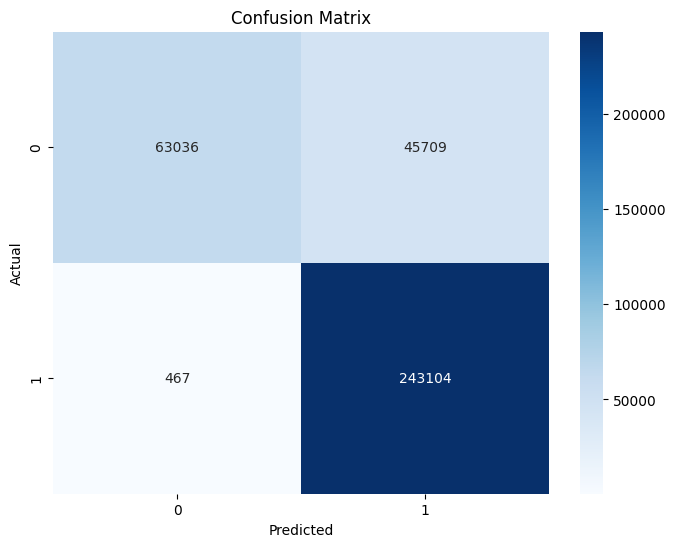

In [23]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# Plot the top feature importances from the trained Random Forest model to interpret model decisions.


C:\Users\ruthe\AppData\Local\Temp\ipykernel_12572\1873710493.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importance_df.head(15), x='Importance', y='Feature', palette='viridis')


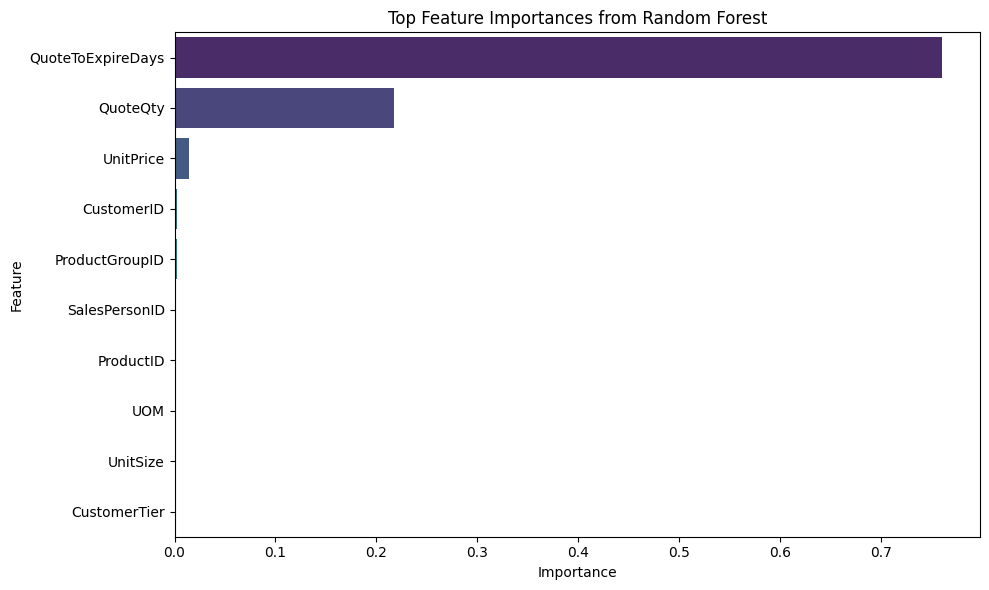

In [24]:
# Plot Feature Importances
importances = rf_model.feature_importances_
feature_names = X.columns

feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top Feature Importances from Random Forest')
plt.tight_layout()
plt.show()